# Harpy - Xenium - Registration and region annotation

## Import packages

In [1]:
import os
import harpy as hp
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import spatialdata_plot

_ = spatialdata_plot

## Read SpatialData
We will read in a fresh SpatialData object from the registry to pick up where we left off in the previous notebook.

In [2]:
import tempfile
from pathlib import Path

from harpy.datasets.registry import get_registry
from spatialdata import read_zarr
from spatialdata.transformations import Identity


tmp = tempfile.TemporaryDirectory(prefix="xenium_")
output_dir = Path(tmp.name)

sdata = hp.datasets.xenium_human_ovarian_cancer(subset=True)
sdata.write(output_dir / "sdata.zarr", overwrite=True)
sdata = read_zarr(sdata.path)

# add vectorized version of the transformation mask (for plotting)
sdata = hp.sh.vectorize(
    sdata,
    labels_name="nucleus_labels_global",
    output_shapes_name="nucleus_shapes_global",
    overwrite=True,
)

cache_dir_path = None  # change this path on Windows

registry = get_registry(path=cache_dir_path)


C:\Users\julien.mortier\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\julien.mortier\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\julien.mortier\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\julien.mortier\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\julien.mortier\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding w

## 4. BigWarp registration

### 4.1 Registration using BigWarp
Since this dataset contains an H&E that was acquired after the Xenium run, we will demonstrate how it can be registered to the fluorescent images and transcript coordinate space using the [BigWarp-plugin](https://imagej.net/plugins/bigwarp) in [FIJI](https://fiji.sc/) and how we can add it to the SpatialData object.

For this notebook, we will follow the instructions as outlined in the README file in this [repository](https://github.com/vibspatial/bigwarp). Open this documentation for detailed instructions if you want to follow along. In short, we will do the following steps:
1. Download the fluorescent images and H&E using the code below.
2. Download an installation with the appropriate versions of FIJI and BigWarp using the link provided in the README document.
3. Open FIJI and create a BigWarp dataset. Select `transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0000.ome.tif` and `transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif` as dataset files.
4. Launch BigWarp. Select `Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image-s0-ch_0` as moving image and `morphology_focus_0000-s0-DAPI` as fixed image.
5. Place landmarks on the DAPI (fixed image) and H&E images (moving image) and set transformation to `Thin Plate Spline`.
6. Export the warped H&E image as TIFF.
7. Add this image to the SpatialData object using the code in this notebook.

Note that we will not create the conda environment as described in the documentation since we will export to TIFF (and not to Zarr).

In [3]:
# To download the images from the registry, run the following code:

# Fetch morphology focus images
path_morphology_focus_0000 = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0000.ome.tif"
)
path_morphology_focus_0001 = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0001.ome.tif"
)
path_morphology_focus_0002 = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0002.ome.tif"
)
path_morphology_focus_0003 = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0003.ome.tif"
)

# Fetch H&E image
path_he_image = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif"
)

### 4.2 Adding the warped H&E image to the SpatialData object

In [4]:
from dask_image.imread import imread

path_warped_image = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/HE_warped_TPS.tiff"
)  # This sets the path to the warped H&E from the registry. You can also supply your own path.

img = imread(path_warped_image)
img

dask.array<_map_read_frame, shape=(1, 37631, 54089, 3), dtype=uint8, chunksize=(1, 37631, 54089, 3), chunktype=numpy.ndarray>

In [5]:
# Squeeze and transpose image for hp.im.add_image()
img = img.squeeze(0).transpose((2, 0, 1))  # Squeeze unused dimension, and transpose to make it (c,y,x)
img

dask.array<transpose, shape=(3, 37631, 54089), dtype=uint8, chunksize=(3, 37631, 54089), chunktype=numpy.ndarray>

In [6]:
# Rechunk image
img = img.rechunk(1024)
img

dask.array<rechunk-merge, shape=(3, 37631, 54089), dtype=uint8, chunksize=(3, 1024, 1024), chunktype=numpy.ndarray>

In [7]:
# Add image to SpatialData
sdata = hp.im.add_image(
    sdata,  # The SpatialData object to which the new image layer will be added.
    arr=img,  # The array containing the image data to be added.
    dims=("c", "y", "x"),  # A tuple specifying the dimensions of the image data
    output_image_name="he_image_bigwarp",  # The name of the output layer where the image data will be stored.
    transformations={
        "global": Identity()
    },  # NOTE: we only add it to the pixel coordinate system "global" for simplicity
    overwrite=True,
    c_coords=["r", "g", "b"],
    scale_factors=(2, 2, 2, 2, 2, 2),  # save as multiscale
)

2026-06-03 16:32:41.059 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'he_image_bigwarp'


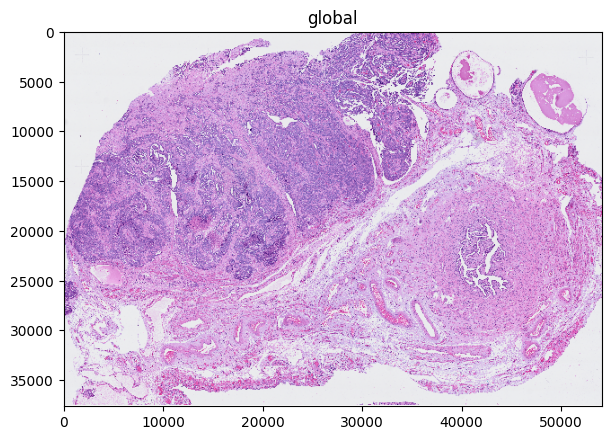

In [8]:
# Plot warped H&E
sdata.pl.render_images(
    element="he_image_bigwarp",
    scale="scale4",
).pl.show(figsize=(6, 5))

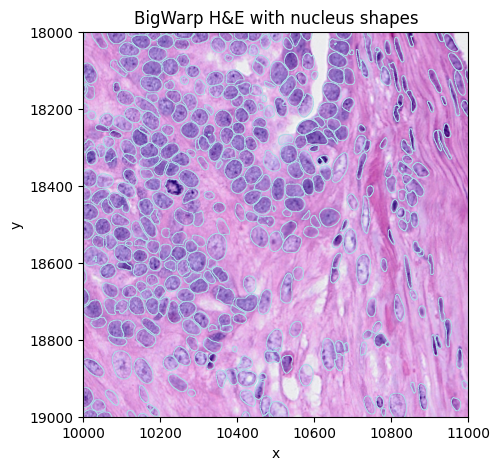

In [9]:
# Let's check whether the H&E is registered correctly to other spatial elements
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(figsize=(5, 5))


sdata_crop.pl.render_images(
    element="he_image_bigwarp",
    scale="scale0",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.6,
    outline_alpha=1,
    outline_color="lightblue",
).pl.show(
    coordinate_systems="global",
    colorbar=False,
    title="BigWarp H&E with nucleus shapes",
    ax=ax,
)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

### 4.3 Adding the original H&E image with an affine transformation
Alternatively, we can use the affine transformation matrix supplied by 10X Genomics and add the original H&E with the affine transformation specified in the SpatialData object. This workflow can be useful if you want to use the affine transformation matrix from BigWarp or some other registration method. Note that nonlinear transformations (e.g. TPS from BigWarp) are not supported by SpatialData.

In [10]:
from spatialdata.transformations import Affine

# Fetch the original H&E image and the known transformation matrix from the registry
path_he_image = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif"
)

path_transformation = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_imagealignment.csv"
)

# Read in the transformation matrix from the CSV file
transformations_df = pd.read_csv(
    path_transformation, header=None
)  # We read in the affine transformation supplied by 10X Genomics as a pandas dataframe.
A = transformations_df.values  # Convert to a numpy array
affine_transform = Affine(A, input_axes=("x", "y"), output_axes=("x", "y"))

# The original H&E image is read using dask image
img = imread(path_he_image)
img = img.squeeze().transpose((2, 0, 1))  # Remove unused dimensions

transformations = {"global": affine_transform}  # for simplicity we do not add the micron coordinate system here

sdata = hp.im.add_image(
    sdata,
    arr=img.rechunk((1, 1024, 1024)),
    dims=("c", "y", "x"),
    output_image_name="he_image_original",
    overwrite=True,
    c_coords=("r", "g", "b"),
    transformations=transformations,  # We can specify the transformations to be added to the image layer here
    scale_factors=(2, 2, 2, 2, 2, 2),
)

2026-06-03 16:34:32.796 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'he_image_original'


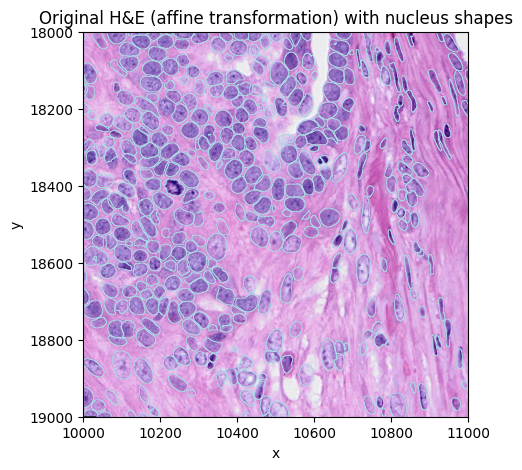

In [11]:
# Let's check whether the H&E is registered correctly to other spatial elements
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(figsize=(5, 5))

sdata_crop.pl.render_images(
    element="he_image_original",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.6,
    outline_alpha=1,
    outline_color="lightblue",
).pl.show(
    coordinate_systems="global",
    colorbar=False,
    title="Original H&E (affine transformation) with nucleus shapes",
    ax=ax,
)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

## 5. Region annotation
We will now create some region annotations on the warped H&E image. This makes sure the region annotations are in the same coordinate space as the fluorescent images and the transcripts. This is by far the easiest and most straight-forward workflow and is usually recommended. We can do this both in Napari and in Qupath.

However, in some cases, you may prefer to annotate on the original unwarped H&E and transform the region annotations according to the BigWarp tranformation. For this more complex scenario, we have created some documentation and tools, which you can find [here](https://github.com/vibspatial/bigwarp/blob/main/transform_geometries/transform_geometries.ipynb).

Note that you also have the option to annotate on the original unwarped H&E and add the region annotations to the SpatialData object with an affine transformation matrix specified (see 4.3). This, of course, requires that you know the affine transformation matrix. Since this is very similar to what was covered in 4.3, we will not cover it here again.

### 5.1 Region annotation in Napari
In napari SpatialData, we will create a new shapes layer (rename the layer to 'region_annotation'), annotate a region of interest, save to sdata using Shift + E and close Napari.

For more info, see [this link](https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/napari_rois.html). Note that there is, currently, only support for saving rectangles, polygons and points.

In [13]:
# Open Napari to create region annotation
from napari_spatialdata import Interactive

Interactive(sdata)

2026-06-03 16:38:54.673 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


In [14]:
# Let's check the sdata object to see whether the element was correctly added
sdata

SpatialData object, with associated Zarr store: C:\Users\julien.mortier\AppData\Local\Temp\xenium_kc_qsm5e\sdata.zarr
├── Images
│     ├── 'he_image_bigwarp': DataTree[cyx] (3, 37631, 54089), (3, 18815, 27044), (3, 9407, 13522), (3, 4703, 6761), (3, 2351, 3380), (3, 1175, 1690), (3, 587, 845)
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     ├── 'he_image_original': DataTree[cyx] (3, 43993, 30918), (3, 21996, 15459), (3, 10998, 7729), (3, 5499, 3864), (3, 2749, 1932), (3, 1374, 966), (3, 687, 483)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global'

In [15]:
# We need to make sure the shapes layer is backed to zarr
from spatialdata import read_zarr

sdata.write_element(element_name="region_annotation")
sdata = read_zarr(sdata.path)
sdata

SpatialData object, with associated Zarr store: C:\Users\julien.mortier\AppData\Local\Temp\xenium_kc_qsm5e\sdata.zarr
├── Images
│     ├── 'he_image_bigwarp': DataTree[cyx] (3, 37631, 54089), (3, 18815, 27044), (3, 9407, 13522), (3, 4703, 6761), (3, 2351, 3380), (3, 1175, 1690), (3, 587, 845)
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     ├── 'he_image_original': DataTree[cyx] (3, 43993, 30918), (3, 21996, 15459), (3, 10998, 7729), (3, 5499, 3864), (3, 2749, 1932), (3, 1374, 966), (3, 687, 483)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global'

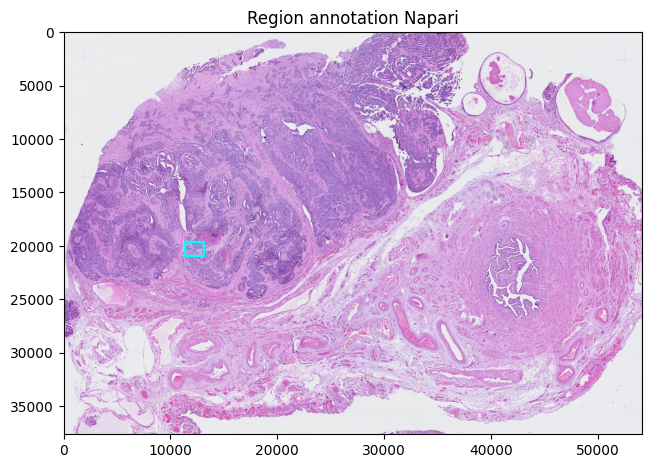

In [16]:
# Let's plot the region annotation
sdata.pl.render_images(element="he_image_bigwarp", scale="scale5").pl.render_shapes(
    element="region_annotation",
    color="cyan",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="cyan",
).pl.show(
    coordinate_systems="global",
    title="Region annotation Napari",
)

In [17]:
# We can export the annotation as a GeoJSON to, for example, to read it into Xenium Explorer or Qupath
sdata.shapes["region_annotation"].to_file(os.path.join(output_dir, "region_annotation.geojson"), driver="GeoJSON")

<b>Excercise</b>:
- Create your own region annotation in Napari, add it to the SpatialData and plot the results.
- BONUS: Can you create an annotation in Xenium Explorer and add it to the SpatialData and plot the results.

### 5.2 Qupath region annotation
Qupath is open source software for bioimage analysis. It has some really nice tools for annotating regions of interest and artifacts in images. We will use these for our dataset and add the results to the SpatialData object.

1. If necessary, install QuPath (v.0.6.0) using this [link](https://qupath.github.io/).
2. Open Qupath and click `Create project` in the top left corner.
3. Create a new empty folder for the project and click `Select Folder`.
4. To add images, go to `Add images` and provide the path to the warped H&E image.
5. Explore the image by going to `Brightness & contrast`, select the channels you want to visualize and adjust the settings to improve the visualization.
6. Annotate a region using the annotation tools.
7. Export the region annotation. Select all artifact annotations you want to export and go to `File`, `Export objects as GeoJSON` and set to `Selected objects` and `Compression` to None. Click `OK` and pick a file name.

In [18]:
# We will add the region annotations we already created based on the annotations supplied by 10X Genomics.
paths_to_GeoJSONs = {
    "tumor": registry.fetch("transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/tumor.geojson"),
    "necrosis": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/necrosis.geojson"
    ),
    "ovary": registry.fetch("transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/ovary.geojson"),
    "fallopian_tube": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/fallopian_tube.geojson"
    ),
    "smooth_muscle": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/smooth_muscle.geojson"
    ),
}

for name, path in paths_to_GeoJSONs.items():
    gdf_regions = gpd.read_file(path)
    sdata = hp.sh.add_shapes(sdata, input=gdf_regions, output_shapes_name=name, overwrite=True)

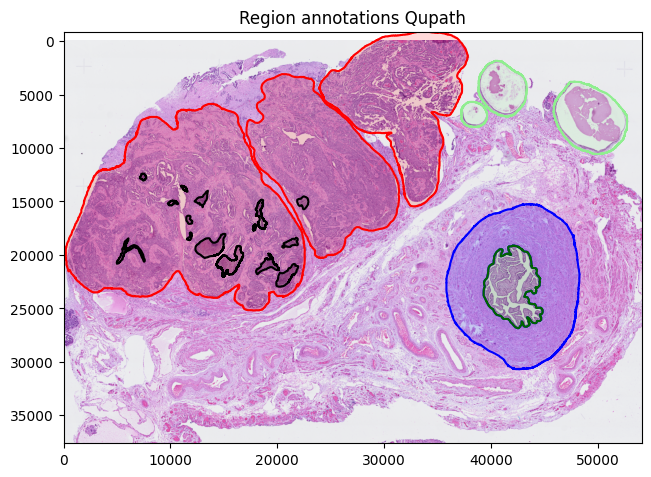

In [19]:
# Let's check whether the region annotations were added correctly
sdata.pl.render_images(element="he_image_bigwarp", scale="scale4").pl.render_shapes(
    element="tumor", color="red", fill_alpha=0.15, outline_alpha=1, outline_color="red"
).pl.render_shapes(
    element="necrosis",
    color="black",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="black",
).pl.render_shapes(
    element="ovary",
    color="lightgreen",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="lightgreen",
).pl.render_shapes(
    element="smooth_muscle",
    color="blue",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="blue",
).pl.render_shapes(
    element="fallopian_tube",
    color="darkgreen",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="darkgreen",
).pl.show(
    coordinate_systems="global",
    title="Region annotations Qupath",
)

In [ ]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

2026-06-03 16:52:13.690 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:13.740 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:13.764 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:13.776 | WARNING  | napari_harpy.viewer._styling:build_string_categorical_values:79 - Coercing plain string/object column `id` to temporary categorical values for viewer coloring.
2026-06-03 16:52:35.327 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:35.356 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:35.378 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-06-03 16:52:35.384 | WARNING  | napari_harpy.viewer._styling:build_string_categorical_values:79 - Coercing plain string/object column `id` to temporary categorical values for viewer coloring.


<b>Excercise</b>:
- Create your own region annotation in Qupath and add it to the SpatialData. Plot the resulting shapes layer.

### 5.3 ADVANCED: Registering region annotations using BigWarp
Follow the steps detailed in this [documentation](https://github.com/vibspatial/bigwarp/blob/main/transform_geometries/transform_geometries.ipynb). To sucessfully run this, you need to download the `vibspatial/bigwarp` github repository, open the `transform_geometries.ipynb` notebook, adjust the paths and follow the instructions.

In this training, we will register one of the region annotations (fallopian_tube.geojson) created in Qupath on the original fluorescent images (since we already have this) and transform it in the reverse direction to coordinate space of the H&E. We can check whether we were successful by opening both the original H&E and the warped region annotation GeoJSON in Qupath.

In short, there are 4 steps we need to do:

<b>Steps</b>:
1. Convert the GeoJSON geometries of fallopian_tube.geojson into a series of coordinates using the `convert_geometries_for_bigwarp` function in the notebook.
2. Transform the exported coordinates according to the BigWarp transformation using the `warp_points_bigwarp.groovy` script in FIJI.
3. Reconstruct GeoJSON geometries from the warped coordinates using the `create_warped_geometries` function in the notebook.
4. Open the original H&E and the warped GeoJSON in Qupath to verify the registration was succesful.

<b>Important note 1 </b>: Since Qupath saves the coordinates in the GeoJSON-file in pixel coordinates, but the BigWarp landmark file that we created earlier contains the landmark coordinates in millimeter, we need to scale the landmark coordinates in the groovy script to pixels. We know that the pixel size of the fixed image (morphology_focus_0000.tiff) is 0.2125 micrometer and the pixel size of moving image (Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif) is 0.2738 micrometer. See settings below.

<b>Important note 2 </b>: Since we are transforming from the fixed image coordinate space to the moving image coordinate space, we need to make sure `Reverse direction` is selected. See settings below.

![alt text](Screenshot.png)